## Partie 1 : Logistic Regression

In [2]:
# ==========================================================
# Import Libraries
# ==========================================================

import pandas as pd
import matplotlib.pyplot as plt

import sys

sys.path.append("../src")
from training import (
    split_features_target,
    standardize_features
)

from evaluation import load_model

In [3]:
# ==========================================================
# Load Dataset
# ==========================================================

TRAIN_PATH = "../data/processed/train.csv"
TEST_PATH = "../data/processed/test.csv"

train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

X_train, X_test, y_train, y_test = split_features_target(
    train_df,
    test_df
)

X_train_scaled, X_test_scaled, scaler = standardize_features(
    X_train,
    X_test
)

Splitting features and target...
Features and target successfully separated.

Standardizing features...
Feature standardization completed.



In [4]:
# ==========================================================
# Load Trained Models
# ==========================================================

logistic_model = load_model("../models/logistic_regression.pkl")

rf_model = load_model("../models/random_forest.pkl")

Loading model from ../models/logistic_regression.pkl...
Model loaded successfully.

Loading model from ../models/random_forest.pkl...
Model loaded successfully.



## Partie 2 : Coefficients de la Logistic Regression

In [5]:
# ==========================================================
# Logistic Regression Coefficients
# ==========================================================

coefficients = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": logistic_model.coef_[0]
})

coefficients

,Feature,Coefficient
0,age,0.333982
1,fnlwgt,0.070830
2,education.num,0.374726
3,capital.gain,2.340926
4,capital.loss,0.266535
...,...,...
103,native.country_Trinadad&Tobago,-0.014289
104,native.country_United-States,0.075239
105,native.country_Unknown,-0.007731
106,native.country_Vietnam,-0.067746


In [6]:
# ==========================================================
# Top Positive Coefficients
# ==========================================================

coefficients.sort_values(
    by="Coefficient",
    ascending=False
).head(10)

,Feature,Coefficient
3,capital.gain,2.340926
33,marital.status_Married-civ-spouse,0.749033
2,education.num,0.374726
5,hours.per.week,0.362450
0,age,0.333982
4,capital.loss,0.266535
58,relationship_Wife,0.256737
41,occupation_Exec-managerial,0.254510
54,relationship_Not-in-family,0.196919
65,sex_Male,0.184706


In [7]:
# ==========================================================
# Most Influential Features
# ==========================================================

coefficients["Absolute Coefficient"] = coefficients["Coefficient"].abs()

coefficients.sort_values(
    by="Absolute Coefficient",
    ascending=False
).head(15)

,Feature,Coefficient,Absolute Coefficient
3,capital.gain,2.340926,2.340926
33,marital.status_Married-civ-spouse,0.749033,0.749033
28,education_Preschool,-0.548310,0.548310
35,marital.status_Never-married,-0.521386,0.521386
2,education.num,0.374726,0.374726
5,hours.per.week,0.362450,0.362450
56,relationship_Own-child,-0.351445,0.351445
0,age,0.333982,0.333982
45,occupation_Other-service,-0.282853,0.282853
46,occupation_Priv-house-serv,-0.276191,0.276191


## Part 3: Random Forest

In [8]:
# ==========================================================
# Random Forest Feature Importance
# ==========================================================

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
1,fnlwgt,0.158363
0,age,0.152403
3,capital.gain,0.091983
5,hours.per.week,0.082076
33,marital.status_Married-civ-spouse,0.068521
2,education.num,0.063034
53,relationship_Husband,0.036102
4,capital.loss,0.030981
35,marital.status_Never-married,0.021546
41,occupation_Exec-managerial,0.017795


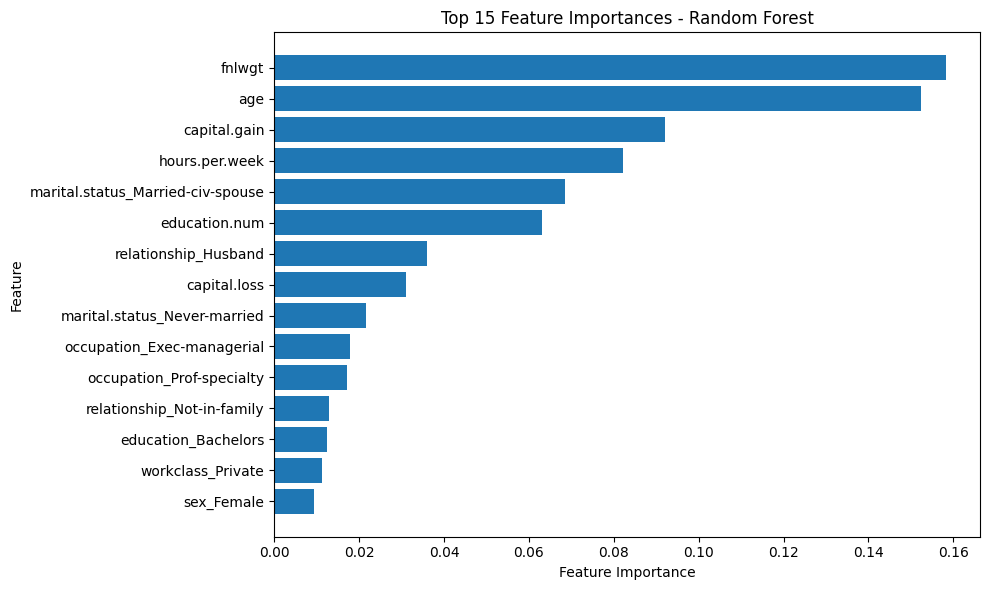

In [9]:
# ==========================================================
# Plot Feature Importance
# ==========================================================

top_features = feature_importance.head(15)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.gca().invert_yaxis()

plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.title("Top 15 Feature Importances - Random Forest")

plt.tight_layout()

plt.show()